In [1]:
%matplotlib inline
import pandas as pd

In [2]:
from IPython.core.display import HTML
css = open('style-table.css').read() + open('style-notebook.css').read()
HTML('<style>{}</style>'.format(css))

In [3]:
titles = pd.read_csv('data/titles.csv')
titles.head()

,title,year
0,Fight and Revenge,1997
1,Royal Shakespeare Company: The Merchant of Venice,2015
2,A Doll's House,1917
3,Shankar IPS,2010
4,Iki basli dev,1990


In [4]:
cast = pd.read_csv('data/cast.csv')
cast.head()

,title,year,name,type,character,n
0,Closet Monster,2015,Buffy #1,actor,Buffy 4,31.0
1,Suuri illusioni,1985,Homo $,actor,Guests,22.0
2,Battle of the Sexes,2017,$hutter,actor,Bobby Riggs Fan,10.0
3,Secret in Their Eyes,2015,$hutter,actor,2002 Dodger Fan,NaN
4,Steve Jobs,2015,$hutter,actor,1988 Opera House Patron,NaN


### Define a year as a "Superman year" whose films feature more Superman characters than Batman. How many years in film history have been Superman years?

In [38]:
c = cast
temp = c[c.character.isin(['Superman', 'Batman'])]
cc = temp.groupby(['year','character']).size()
cc = cc.unstack()
cc = cc.fillna(0)
cc = cc[cc['Superman']>cc['Batman']]
print('Num of Superman years: ', len(cc))


Num of Superman years:  11


### How many years have been "Batman years", with more Batman characters than Superman characters?

In [47]:
c = cast
c = c[c.character.isin(['Batman','Superman'])]
cc = c.groupby(['year','character']).size()
cc = cc.unstack()
cc = cc.fillna(0)
cc = cc[cc['Batman']>cc['Superman']]
print('Num of Batman years: ', len(cc))

Num of Batman years:  26


### Plot the number of actor roles each year and the number of actress roles each year over the history of film.

<Axes: xlabel='year'>

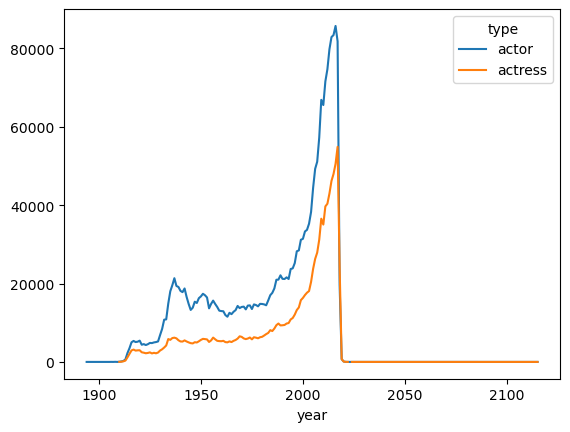

In [14]:
c = cast
c = c.groupby(['year','type']).size()
c = c.unstack()
c.plot(kind='line')

### Plot the number of actor roles each year and the number of actress roles each year, but this time as a kind='area' plot.

<Axes: xlabel='year'>

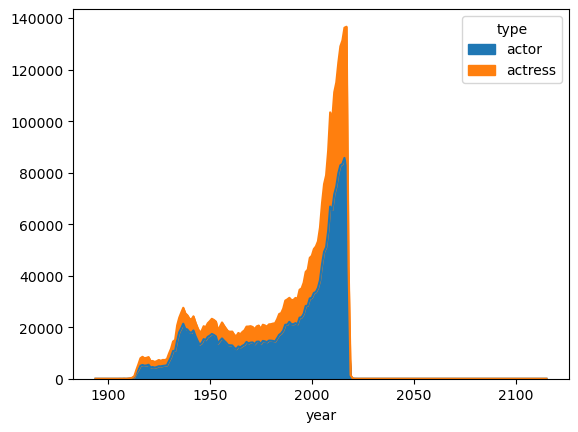

In [20]:
c = cast
c = c.groupby(['year','type']).size()
c = c.unstack()
c.plot(kind='area')

### Plot the difference between the number of actor roles each year and the number of actress roles each year over the history of film.

<Axes: xlabel='year'>

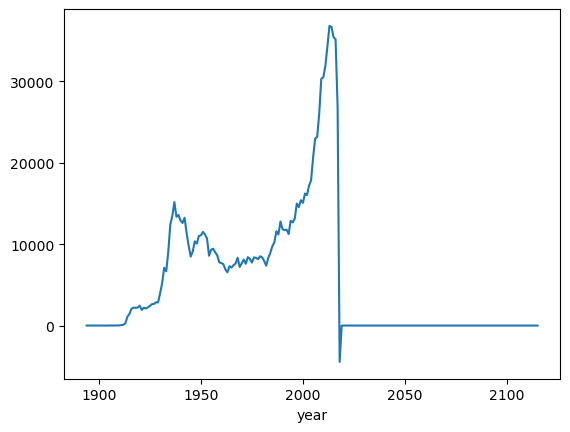

In [8]:
c = cast
c = c.groupby(['year','type']).size().unstack().fillna(0)
(c.actor - c.actress).plot()

### Plot the fraction of roles that have been 'actor' roles each year in the history of film.

<Axes: xlabel='year'>

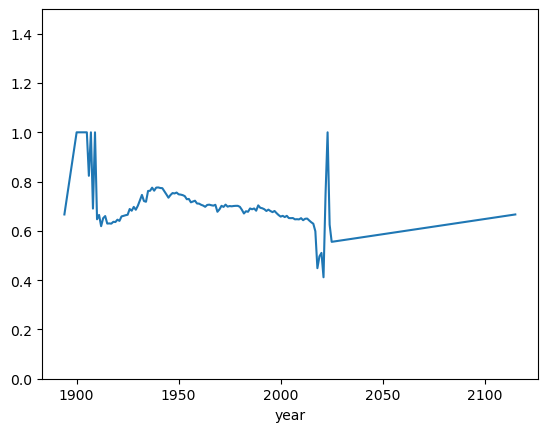

In [31]:
c = cast
c = c.groupby(['year','type']).size().unstack().fillna(0)
c['total'] = c['actor'] + c['actress']
c['actor_frac'] = c['actor'] / c['total']
c['actor_frac'].plot(ylim=(0,1.5))


### Plot the fraction of supporting (n=2) roles that have been 'actor' roles each year in the history of film.

<Axes: xlabel='year'>

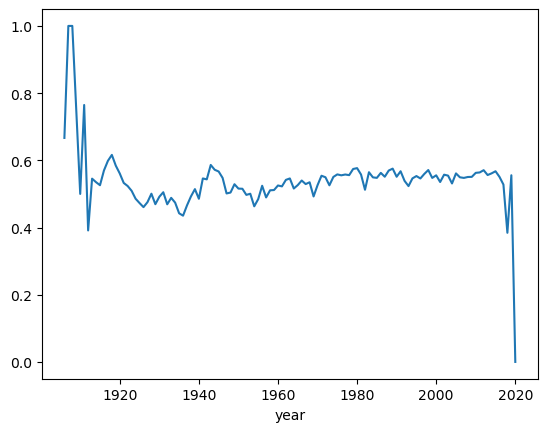

In [40]:
c = cast
c = c[c.n == 2]
c = c.groupby(['year','type']).size().unstack().fillna(0)
c['actor_frac'] = (c.actor / (c.actor + c.actress))
c['actor_frac'].plot()

### Build a plot with a line for each rank n=1 through n=3, where the line shows what fraction of that rank's roles were 'actor' roles for each year in the history of film.

In [10]:
c = cast
c = c[c.n.isin([1,2,3])]
c = c.groupby(['year','type','n']).size()
c = c.unstack().fillna(0)
c

n               1.0    2.0    3.0
year type                        
1906 actor      2.0    2.0    0.0
     actress    1.0    1.0    1.0
1907 actor      1.0    1.0    1.0
1908 actor      1.0    2.0    2.0
1909 actor      1.0    0.0    0.0
...             ...    ...    ...
2018 actress  440.0  471.0  389.0
2019 actor     11.0   10.0    6.0
     actress   16.0    8.0   11.0
2020 actor      4.0    0.0    0.0
     actress    0.0    1.0    0.0

[227 rows x 3 columns]